<a href="https://colab.research.google.com/github/davimoraes-dev/Inteligencia-Artificial/blob/main/fishmorph_svm_davimoraes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificando peixes com SVM (dataset FISHMORPH)

- Importa o dataset
- Faça uma analise dos dados padrão - tiro nulls etc
- Distribuicao das categorias - visualizar os dados
- Divisão teste treino - Cross validation
- Gread Search - teste kernel 4 valores diferentes para cada hiperparametro (kernel, c e gama)
- Qual o valor de acurácia do modelo, qual o modelo, qual os parâmetros do modelo
- Acurácia e matriz de confusão

## Baixando os dados do Kaggle

O `kagglehub` puxa o dataset direto do Kaggle pro Colab. Como esse dataset é público, não precisa fazer login nem nada.

In [1]:
!pip install -q kagglehub
import kagglehub, os

path = kagglehub.dataset_download("menegidio/fishmorph-dataset")
print("Os arquivos ficaram em:", path)

# mostra o que veio dentro da pasta
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

Using Colab cache for faster access to the 'fishmorph-dataset' dataset.
Os arquivos ficaram em: /kaggle/input/fishmorph-dataset
/kaggle/input/fishmorph-dataset/FISHMORPH_Order_Dataset.csv
/kaggle/input/fishmorph-dataset/FISHMORPH_Family_Dataset.csv


## Abrindo a tabela

Aqui eu só abro o arquivo e dou uma olhada nas primeiras linhas pra ver o jeitão dos dados.

In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# pega o CSV que veio na pasta (o sep=None descobre sozinho se é separado por vírgula ou ponto e vírgula)
arquivos = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
df = pd.read_csv(arquivos[0], sep=None, engine="python", encoding="latin-1")

print("Linhas e colunas:", df.shape)
df.head()

Linhas e colunas: (8342, 11)


,MBl,BEl,VEp,REs,OGp,RMl,BLs,PFv,PFs,CPt,Order
0,130.0,4.579113,0.622642,0.375019,0.622642,0.868659,0.484981,0.273585,0.144108,3.348991,Cypriniformes
1,11.5,2.796068,0.650700,0.353780,0.509800,0.411157,0.722461,0.330169,0.221095,2.525592,Perciformes
2,6.6,4.564329,0.518187,0.312002,0.203985,0.413221,0.591495,0.105517,0.188193,2.104580,Cypriniformes
3,10.9,4.390422,0.548247,0.244804,0.168959,0.324728,0.642991,0.097450,0.193049,1.787062,Cypriniformes
4,18.9,4.410271,0.542353,0.292058,0.183790,0.398567,0.685672,0.087643,0.170648,2.968906,Cypriniformes


In [3]:
# tipo de cada coluna e quantos valores preenchidos ela tem
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8342 entries, 0 to 8341
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MBl     8342 non-null   float64
 1   BEl     8342 non-null   float64
 2   VEp     8342 non-null   float64
 3   REs     8342 non-null   float64
 4   OGp     8342 non-null   float64
 5   RMl     8342 non-null   float64
 6   BLs     8342 non-null   float64
 7   PFv     8342 non-null   float64
 8   PFs     8342 non-null   float64
 9   CPt     8342 non-null   float64
 10  Order   8342 non-null   object 
dtypes: float64(10), object(1)
memory usage: 717.0+ KB


In [4]:
# um resumo rápido: média, menor valor, maior valor etc.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
MBl,8342.0,NaN,NaN,NaN,22.004517,33.612007,1.2,7.0,12.6,24.5,800.0
BEl,8342.0,NaN,NaN,NaN,4.452438,2.338235,1.033084,3.139102,4.038851,5.002621,43.728161
VEp,8342.0,NaN,NaN,NaN,0.549087,0.094883,0.159248,0.487993,0.546213,0.605125,1.0
REs,8342.0,NaN,NaN,NaN,0.391665,0.132814,0.0,0.293205,0.389429,0.486221,1.026667
OGp,8342.0,NaN,NaN,NaN,0.381768,0.194352,0.0,0.278014,0.406904,0.516001,1.026316
RMl,8342.0,NaN,NaN,NaN,0.399786,0.302658,0.0,0.257999,0.361436,0.490671,7.060344
BLs,8342.0,NaN,NaN,NaN,0.571818,0.117486,0.224525,0.490052,0.564739,0.648039,1.230105
PFv,8342.0,NaN,NaN,NaN,0.285316,0.155629,0.0,0.193134,0.275039,0.368876,0.857097
PFs,8342.0,NaN,NaN,NaN,0.189343,0.056109,0.0,0.157972,0.183497,0.215031,0.511113
CPt,8342.0,NaN,NaN,NaN,2.560795,1.016659,0.0,1.999744,2.436329,2.919818,15.452061


## Procurando buracos nos dados

Às vezes tem célula vazia na tabela. Antes de qualquer coisa vale ver quantas são e em quais colunas aparecem.

       vazios    %
MBl         0  0.0
BEl         0  0.0
VEp         0  0.0
REs         0  0.0
OGp         0  0.0
RMl         0  0.0
BLs         0  0.0
PFv         0  0.0
PFs         0  0.0
CPt         0  0.0
Order       0  0.0


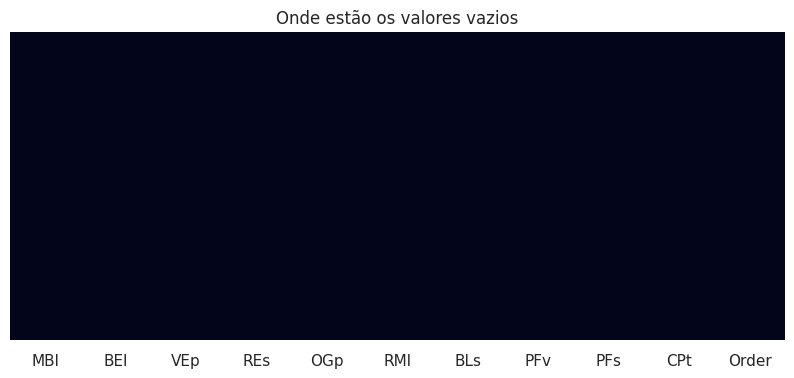

In [5]:
vazios = df.isnull().sum()
print(pd.DataFrame({"vazios": vazios, "%": (vazios / len(df) * 100).round(2)}))

# no gráfico, cada risquinho claro é uma célula vazia
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Onde estão os valores vazios")
plt.show()

Vou tirar as linhas repetidas e as que têm algum valor vazio. Sobra bastante dado, então não faz falta.

In [6]:
print("Linhas repetidas:", df.duplicated().sum())
df = df.drop_duplicates()
df = df.dropna()
print("Depois da limpeza ficou:", df.shape)

Linhas repetidas: 1
Depois da limpeza ficou: (8341, 11)


## O que a gente quer prever

A tabela tem o nome da espécie, a família, a ordem e várias medidas do corpo do peixe (tamanho, posição do olho, formato da nadadeira, essas coisas).

Escolhi prever a **ordem** (`Order`). As medidas são o que o modelo vai usar pra chutar a resposta.

In [7]:
# se a coluna tiver outro nome no seu arquivo, é só trocar aqui
ALVO = [c for c in df.columns if c.lower() == "order"][0]

# as medidas são as colunas com número
medidas = df.select_dtypes(include=np.number).columns.tolist()

print("Vou prever:", ALVO)
print("Usando as medidas:", medidas)
print("Quantas ordens diferentes existem:", df[ALVO].nunique())

Vou prever: Order
Usando as medidas: ['MBl', 'BEl', 'VEp', 'REs', 'OGp', 'RMl', 'BLs', 'PFv', 'PFs', 'CPt']
Quantas ordens diferentes existem: 32


## Quantos peixes tem de cada ordem

Order
Cypriniformes         1933
Perciformes           1826
Siluriformes          1800
Characiformes         1281
Cyprinodontiformes     554
Osteoglossiformes      156
Clupeiformes           104
Gymnotiformes          101
Salmoniformes           92
Atheriniformes          71
Scorpaeniformes         70
Osmeriformes            69
Synbranchiformes        48
Beloniformes            33
Tetraodontiformes       31
Pleuronectiformes       28
Acipenseriformes        23
Mugiliformes            18
Syngnathiformes         16
Anguilliformes          16
Gasterosteiformes       13
Gonorynchiformes        10
Esociformes             10
Polypteriformes          9
Lepisosteiformes         6
Percopsiformes           6
Elopiformes              5
Batrachoidiformes        4
Gadiformes               3
Gobiesociformes          3
Name: count, dtype: int64


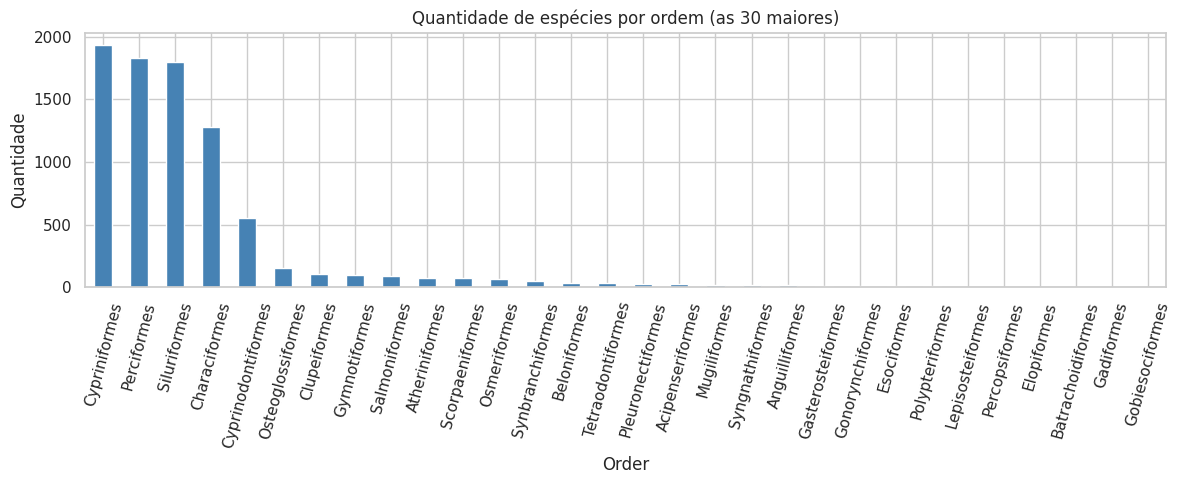

In [8]:
contagem = df[ALVO].value_counts()
print(contagem.head(30))

plt.figure(figsize=(12, 5))
contagem.head(30).plot(kind="bar", color="steelblue")
plt.title("Quantidade de espécies por ordem (as 30 maiores)")
plt.ylabel("Quantidade")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Dá pra ver que umas poucas ordens têm muita espécie e um monte de outras têm quase nada. Com tão poucos exemplos o modelo não tem como aprender essas ordens pequenas, então vou ficar só com as 8 maiores.

Tamanho da base que vai pro modelo: (7755, 11)


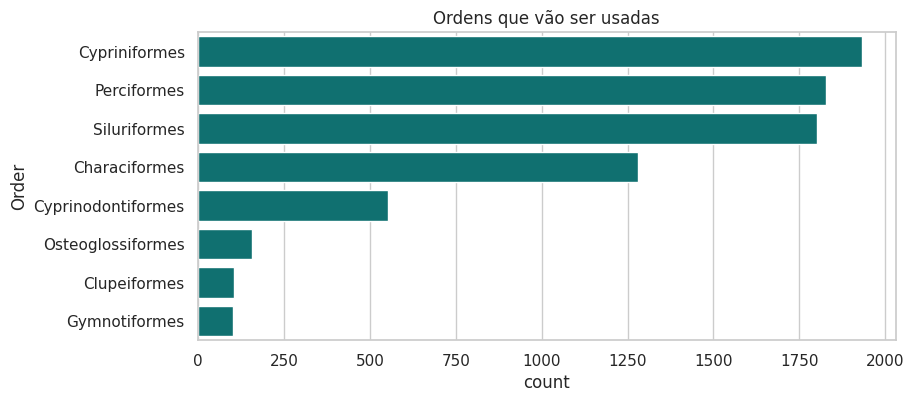

In [9]:
TOP_N = 8  # pode mudar se quiser testar com mais ou menos ordens
ordens_escolhidas = contagem.head(TOP_N).index
dados = df[df[ALVO].isin(ordens_escolhidas)].copy()
print("Tamanho da base que vai pro modelo:", dados.shape)

plt.figure(figsize=(9, 4))
sns.countplot(data=dados, y=ALVO, order=ordens_escolhidas, color="teal")
plt.title("Ordens que vão ser usadas")
plt.show()

## Olhando as medidas

Primeiro como cada medida se espalha no geral, depois comparando entre as ordens. Se uma medida muda bastante de uma ordem pra outra, é sinal de que ela ajuda o modelo.

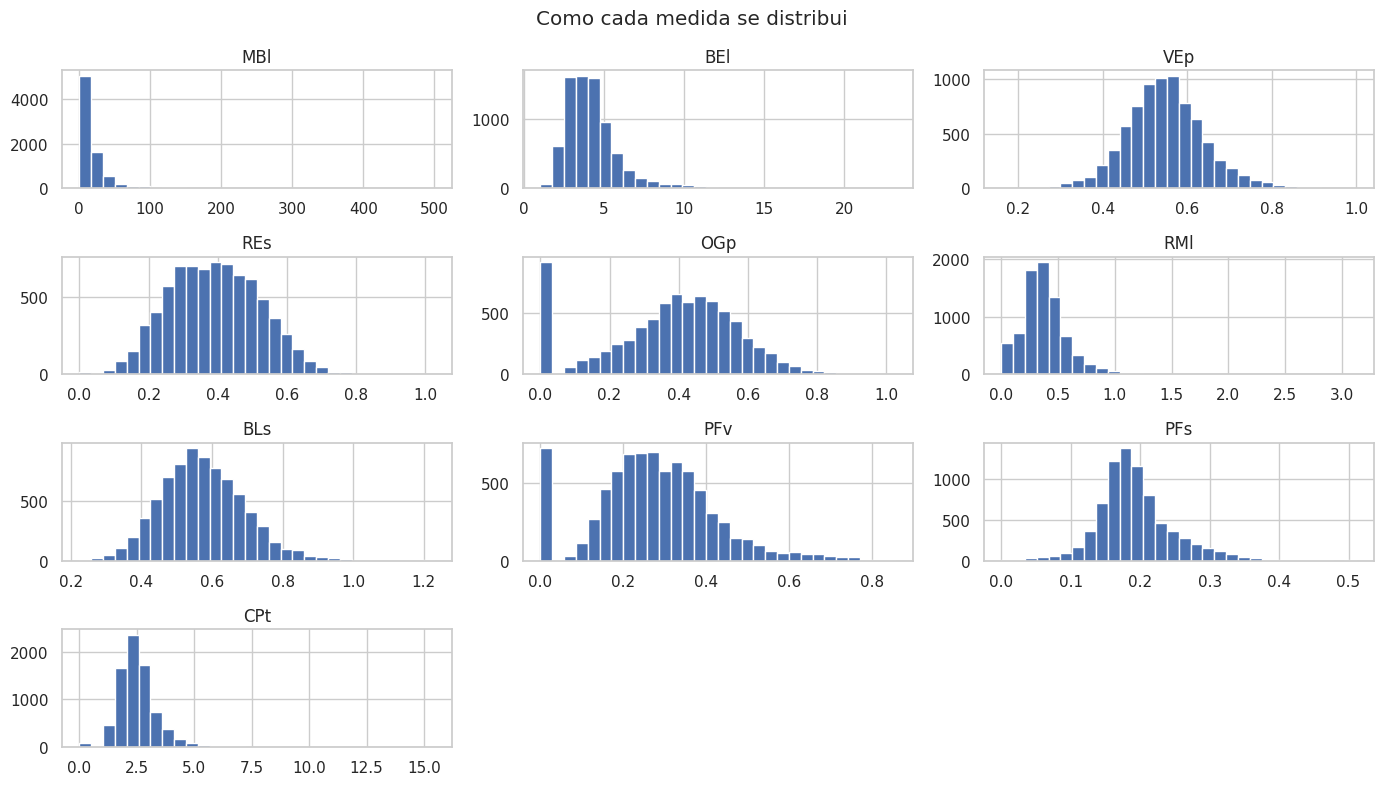

In [10]:
dados[medidas].hist(bins=30, figsize=(14, 8))
plt.suptitle("Como cada medida se distribui")
plt.tight_layout()
plt.show()

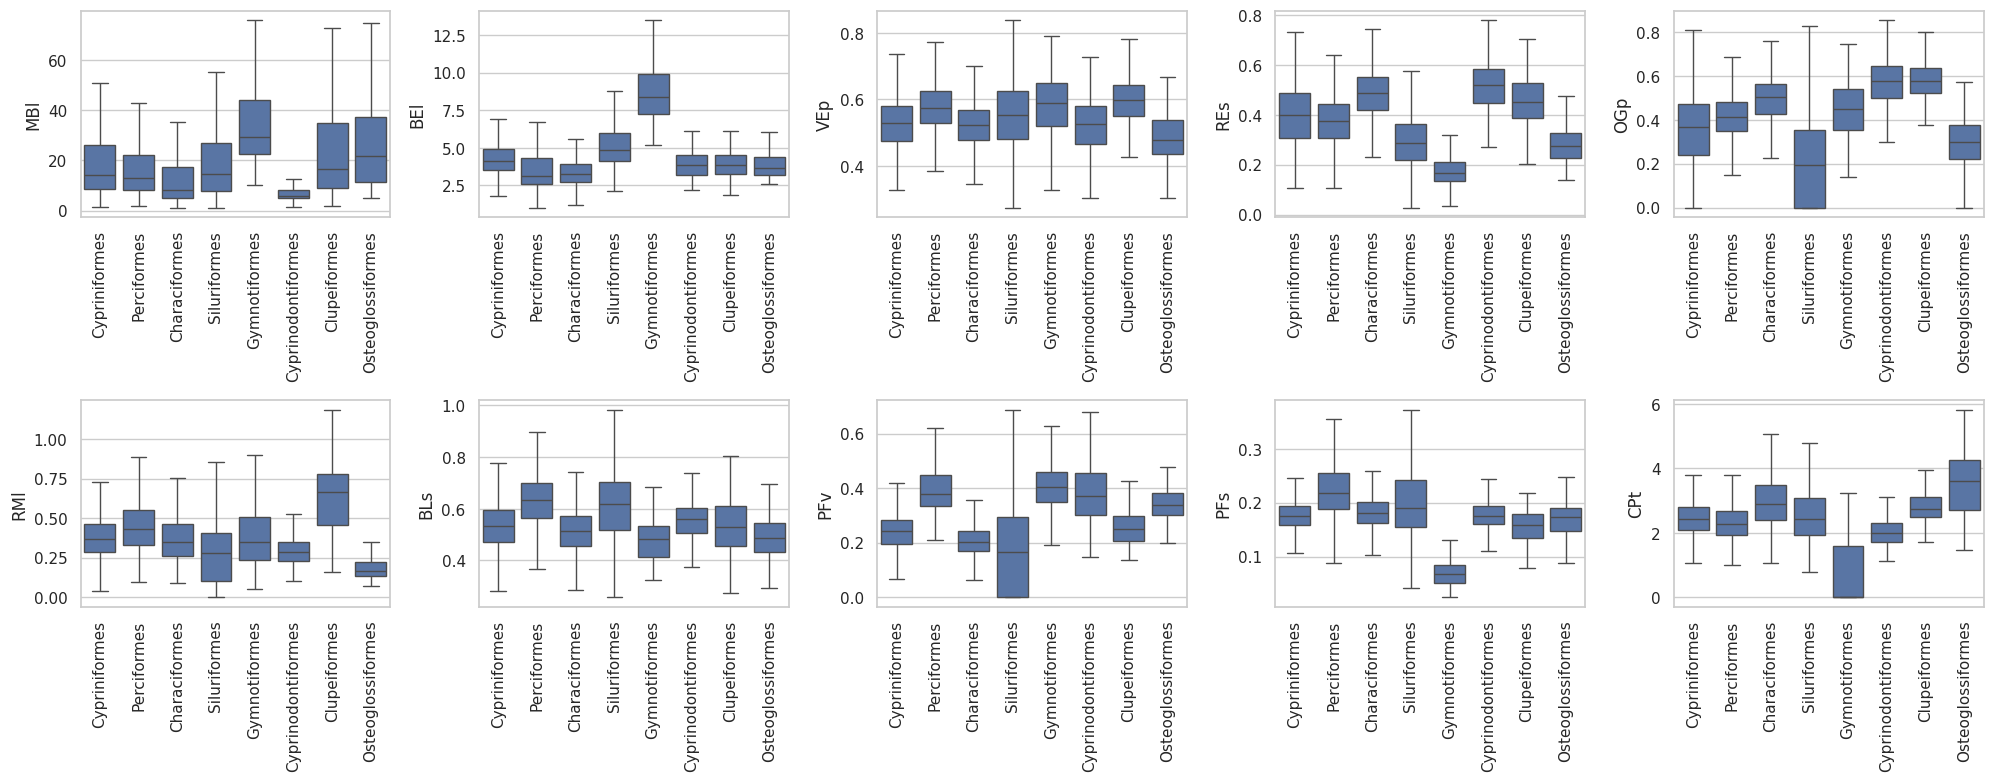

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flat, medidas):
    sns.boxplot(data=dados, x=ALVO, y=col, ax=ax, showfliers=False)
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("")
# esconde os quadrinhos que sobrarem vazios
for ax in axes.flat[len(medidas):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

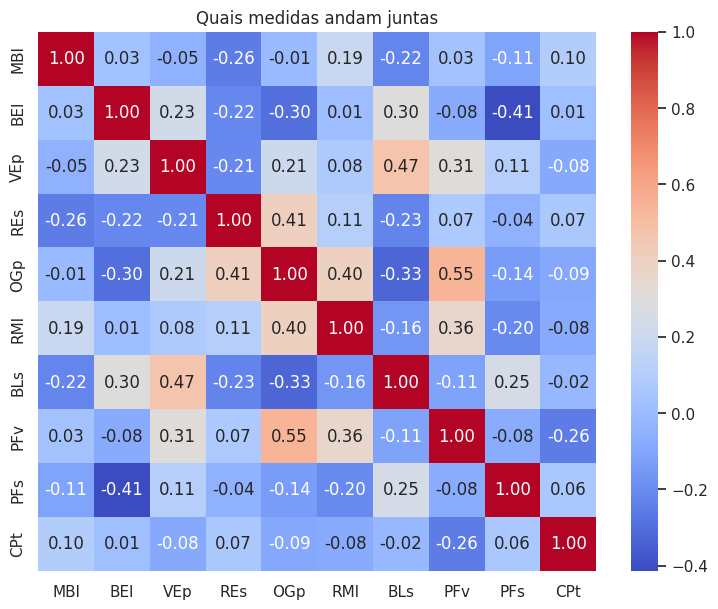

In [12]:
# quanto mais perto de 1 (ou -1), mais duas medidas andam juntas
plt.figure(figsize=(9, 7))
sns.heatmap(dados[medidas].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Quais medidas andam juntas")
plt.show()

## Separando treino e teste

Guardo 20% dos dados num canto e o modelo nunca vê essa parte durante o treino. No final uso ela pra conferir se ele aprendeu de verdade ou só decorou.

Também faço o cross validation: divido o treino em 5 pedaços, treino com 4 e testo no que sobrou, e repito isso 5 vezes trocando o pedaço. Assim a nota não depende da sorte de uma divisão só.

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

X = dados[medidas]
y = dados[ALVO]

# stratify=y faz o treino e o teste ficarem com a mesma proporção de cada ordem
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

# o SVM se perde quando uma medida está em escala muito maior que outra,
# então o StandardScaler deixa todas na mesma escala antes
modelo = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
notas = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")
print("Acerto em cada uma das 5 rodadas:", notas.round(4))
print(f"Média: {notas.mean():.4f}")

Treino: (6204, 10) | Teste: (1551, 10)
Acerto em cada uma das 5 rodadas: [0.8066 0.8131 0.8098 0.805  0.8137]
Média: 0.8096


## Procurando a melhor configuração (GridSearch)

O SVM tem três ajustes principais:

- **kernel**: o "formato" da fronteira que separa as classes (reta, curva etc.)
- **C**: o quanto o modelo aceita errar no treino. Valor alto quer acertar tudo, valor baixo é mais tranquilo
- **gamma**: o quanto cada ponto influencia a fronteira

Vou testar 4 opções de cada. Dá 64 combinações, cada uma passando pelas 5 rodadas do cross validation, então demora uns minutinhos.

In [ ]:
from sklearn.model_selection import GridSearchCV

opcoes = {
    "svm__kernel": ["linear", "rbf", "poly", "sigmoid"],
    "svm__C":      [0.1, 1, 10, 100],
    "svm__gamma":  [0.001, 0.01, 0.1, 1],
}

grid = GridSearchCV(modelo, opcoes, cv=cv, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [ ]:
# as 10 combinações que foram melhor
resultados = pd.DataFrame(grid.cv_results_)[
    ["param_svm__kernel", "param_svm__C", "param_svm__gamma", "mean_test_score"]
].sort_values("mean_test_score", ascending=False)
resultados.head(10)

In [ ]:
# comparando kernel e C lado a lado (pegando o melhor gamma de cada um)
tabela = resultados.groupby(["param_svm__kernel", "param_svm__C"])["mean_test_score"].max().unstack()
plt.figure(figsize=(7, 4))
sns.heatmap(tabela, annot=True, fmt=".3f", cmap="viridis")
plt.title("Acerto por kernel e C")
plt.show()

## Quem ganhou

In [ ]:
melhor = grid.best_estimator_
print("Modelo:", melhor.named_steps["svm"])
print("Melhores parâmetros:", grid.best_params_)
print(f"Acurácia no cross validation: {grid.best_score_:.4f}")

## Os dados que ficaram guardados

Agora sim o modelo vê os 20% que separei lá no começo. A matriz de confusão mostra onde ele acertou e onde se confundiu. A diagonal são os acertos, o resto é quando ele achou que era uma ordem e na verdade era outra.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = melhor.predict(X_test)
print(f"Acurácia no teste: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, labels=melhor.classes_),
                       display_labels=melhor.classes_).plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusão")
plt.tight_layout()
plt.show()

## Conclusão

- **Modelo:** SVM, com as medidas colocadas na mesma escala antes
- **Melhores parâmetros:** kernel = rbf, C = 10, gamma = 0,1
- **Acurácia no cross validation:** 0,71 = 71%
- **Acurácia no teste:** 0,70 = 70%
- Ordens que o modelo mais confundiu: Perciformes e Cypriniformes